In [1]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os
from scipy.stats import linregress

In [2]:
import sys
sys.path.append('..')
from ridesharing_simulation_gradient_calc import *

In [24]:
lr = 0.001

In [3]:
start_week = 0
T0_pricing_params = (5, 0.78, 1.82)

In [4]:
total_weeks = 1

In [5]:
for w in tqdm(range(total_weeks)):
    simulation_this_week = WeeklySimulation(w, lr, T0_pricing_params, None, "")
    for d in range(7):
        drivers_this_week_today = simulation_this_week.simulate_supply()
        requests_this_week_today = simulation_this_week.simulate_demand()
        with open('../data/update_gradient/1_week/exposed_prices_day_'+str(d)+'.json', 'w') as json_file:
            json.dump(simulation_this_week.exposed_prices, json_file, indent=4)

        simulation_this_week.request_driver_matching(verbose=0)
        simulation_this_week.update_gamma_distns()

100%|██████████| 1/1 [00:00<00:00,  2.22it/s]


In [6]:
exposed_price_df = pd.read_json('../data/update_gradient/1_week/exposed_prices_week_0.json')

In [7]:
exposed_price_df.head()

,price_of_ride,distance_normalized_price,trip_duration,trip_miles,rider_acceptance_prob,driver_acceptance_prob,both_accepted
0,23.5463,4.2999,11,5.4760,0.6548,0.5523,0
1,23.4699,4.3191,11,5.4340,0.6539,0.5509,0
2,18.4293,4.6655,8,3.9501,0.6380,0.5251,0
3,29.0880,4.0204,14,7.2352,0.6673,0.5729,0
4,18.7961,4.5273,8,4.1517,0.6444,0.5354,0


In [10]:
len(exposed_price_df), len(exposed_price_df[exposed_price_df.both_accepted==1])

(936, 310)

In [9]:
exposed_price_df[exposed_price_df.both_accepted==1]['price_of_ride'].sum() * simulation_this_week.charge_percentage

2255.74512

In [ ]:
exposed_price_df['ride_grad'] = simulation_this_week.charge_percentage*exposed_price_df.rider_acceptance_prob*exposed_price_df.driver_acceptance_prob* \
(1+exposed_price_df.distance_normalized_price*(\
(1-exposed_price_df.rider_acceptance_prob)*simulation_this_week.b_r)+(1-exposed_price_df.driver_acceptance_prob)*simulation_this_week.b_d)

In [ ]:
exposed_price_df['ride_gradient_theta1'] = exposed_price_df.ride_grad * 2 * exposed_price_df.trip_miles

In [ ]:
exposed_price_df['ride_gradient_theta2'] = exposed_price_df.ride_grad * exposed_price_df.trip_miles

In [ ]:
exposed_price_df[['ride_grad', 'ride_gradient_theta1', 'ride_gradient_theta2']].mean()

ride_grad               0.054739
ride_gradient_theta1    0.659497
ride_gradient_theta2    0.329749
dtype: float64

### Update Policy W matrix based on gradient and context vector
### thetas = W * context, thetas is of (3, 1), W is of (3, 13), context is of (13, 1)
### W is initialized with random numbers
### context vector: One-hot encoding of the day of the week (7 dimensions), Profits from previous days in the week (6 dimensions)
### W[action] = W[action] - learning_rate * gradient(of that action) * context, this update is performed separately for each action (theta).

In [ ]:
context = np.zeros(13)

In [ ]:
context[0] = 1

In [ ]:
context

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

### initialize W matrix

In [15]:
W = np.random.rand(3,13)

In [16]:
W

array([[0.11814886, 0.56451771, 0.23854585, 0.94685256, 0.76391748,
        0.06588275, 0.05918908, 0.62385543, 0.8044074 , 0.48772318,
        0.94472461, 0.56602016, 0.07713681],
       [0.5411248 , 0.924053  , 0.00598003, 0.31102091, 0.97252881,
        0.61919578, 0.12840795, 0.83264632, 0.65791619, 0.73597652,
        0.4876606 , 0.44076564, 0.64784811],
       [0.23062055, 0.78583737, 0.39870138, 0.93621442, 0.47560668,
        0.78196021, 0.08798174, 0.20475341, 0.85847236, 0.83670287,
        0.98434027, 0.6550539 , 0.09006016]])

In [22]:
context_vec_test = np.array([0, 1, 0, 0, 0, 0, 0, 2000, 0, 0, 0, 0, 0])

In [28]:
np.matmul(W[0], context_vec_test)

1248.2753848791515

### update W based on gradient and context vector
### context vector will be updated every day and reset every week(it has memory only within the same week)

In [3]:
rewards_lst = []
max_reward = 0
l2_lambda = 0.01
lr = 0.001
lr_decay_factor = 0.95

grad_total_weeks = 10
simdata_folder = '../data/update_gradient/10_weeks/'

W = np.random.rand(3,13)
pricing_params = (5, 0.78, 1.82)

print('W:', W)

context_prev_rewards = np.zeros(6)

for w in tqdm(range(grad_total_weeks)):
    learning_rate = lr * (lr_decay_factor ** w)
    print('learning_rate:', learning_rate)
    simulation_this_week = WeeklySimulation(w, lr, pricing_params, None, "")
    
    for d in range(7):
        context_day_of_week = np.zeros(7)
        context_day_of_week[d] = 1
        
        if d > 0:
            context_prev_rewards[d-1] = rewards_lst[-1]
             
            if context_prev_rewards[d-1]<0:
                context_prev_rewards[d-1] = 0
        
        context_vec = np.concatenate([context_day_of_week, context_prev_rewards])
        print('context_vec:', context_vec)

        drivers_this_week_today = simulation_this_week.simulate_supply()
        requests_this_week_today = simulation_this_week.simulate_demand()

        simulation_this_week.request_driver_matching(verbose=0)
        simulation_this_week.update_gamma_distns()
        
        simdata_filename = 'exposed_prices_'+'week_'+str(w)+'_day_'+str(d)+'.json'
        with open(os.path.join(simdata_folder,simdata_filename), 'w') as json_file:
            json.dump(simulation_this_week.exposed_prices, json_file, indent=4)

        exposed_price_df = pd.read_json(os.path.join(simdata_folder, simdata_filename))
        print(f"num of exposed prices:%d, num of matched prices:%d"%(len(exposed_price_df), len(exposed_price_df[exposed_price_df.both_accepted==1])))

        todays_rewards = exposed_price_df[exposed_price_df.both_accepted==1]['price_of_ride'].sum() * simulation_this_week.charge_percentage

        rewards_lst.append(todays_rewards)

        exposed_price_df['ride_grad'] = simulation_this_week.charge_percentage*exposed_price_df.rider_acceptance_prob*exposed_price_df.driver_acceptance_prob* \
                        (1+exposed_price_df.distance_normalized_price*(\
                        (1-exposed_price_df.rider_acceptance_prob)*simulation_this_week.b_r)+(1-exposed_price_df.driver_acceptance_prob)*simulation_this_week.b_d)

        exposed_price_df['ride_gradient_theta1'] = exposed_price_df.ride_grad * 2 * exposed_price_df.trip_miles
        exposed_price_df['ride_gradient_theta2'] = exposed_price_df.ride_grad * exposed_price_df.trip_miles
        exposed_price_mean_df = exposed_price_df[['ride_grad', 'ride_gradient_theta1', 'ride_gradient_theta2']].mean()
        
        W[0] = W[0] - lr * (exposed_price_mean_df.ride_grad * context_vec + l2_lambda * W[0])
        W[1] = W[1] - lr * (exposed_price_mean_df.ride_gradient_theta1 * context_vec + l2_lambda * W[1])
        W[2] = W[2] - lr * (exposed_price_mean_df.ride_gradient_theta2 * context_vec + l2_lambda * W[2])

        pricing_params = np.matmul(W, context_vec)

        #print('W:', W)
        print('pricing_params:', pricing_params)

W: [[0.3930606  0.888566   0.28051488 0.31133906 0.46586685 0.54933633
  0.72975461 0.38354849 0.28896346 0.93780177 0.7773531  0.1411956
  0.8560993 ]
 [0.4944307  0.35390573 0.50458046 0.67218068 0.26140413 0.05752565
  0.68792036 0.82030599 0.70652604 0.26018036 0.78813424 0.18514844
  0.84725875]
 [0.29613501 0.37344321 0.7909055  0.74053518 0.66074314 0.97812951
  0.26407101 0.86662209 0.60002785 0.36507296 0.79285726 0.78896098
  0.37093485]]


  0%|          | 0/10 [00:00<?, ?it/s]

learning_rate: 0.001
context_vec: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
num of exposed prices:148, num of matched prices:49
pricing_params: [0.39300408 0.49383687 0.29583761]
context_vec: [  0.      1.      0.      0.      0.      0.      0.    353.259   0.
   0.      0.      0.      0.   ]
num of exposed prices:252, num of matched prices:94
pricing_params: [129.63464036 210.15253292 266.52134577]
context_vec: [  0.        0.        1.        0.        0.        0.        0.
 353.259   676.50597   0.        0.        0.        0.     ]
num of exposed prices:396, num of matched prices:142
pricing_params: [292.58694046 313.08423943 485.26056869]
context_vec: [0.00000000e+00 0.00000000e+00 0.00000000e+00 1.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 3.53259000e+02
 6.76505970e+02 1.02945954e+03 0.00000000e+00 0.00000000e+00
 0.00000000e+00]
num of exposed prices:537, num of matched prices:186
pricing_params: [1168.90798474 -465.22618794  337.86348824]
context_vec: [0.000

 10%|█         | 1/10 [00:00<00:04,  2.03it/s]

num of exposed prices:729, num of matched prices:247
pricing_params: [ 1923.16968167 -5185.88652301  -382.43276785]
context_vec: [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 1.00000000e+00 3.53259000e+02
 6.76505970e+02 1.02945954e+03 1.34450367e+03 1.58449881e+03
 1.78358583e+03]
num of exposed prices:893, num of matched prices:303
pricing_params: [ 2951.68891708 -9536.46217112 -2652.75050819]
learning_rate: 0.00095
context_vec: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
num of exposed prices:108, num of matched prices:66
pricing_params: [0.39282642 0.49217768 0.29500459]
context_vec: [ 0.  1.  0.  0.  0.  0.  0. 99.  0.  0.  0.  0.  0.]
num of exposed prices:187, num of matched prices:107
pricing_params: [ 25.94828189 -69.07690276  10.84439524]
context_vec: [  0.    0.    1.    0.    0.    0.    0.   99.  160.5   0.    0.    0.
   0. ]
num of exposed prices:298, num of matched prices:178
pricing_params: [  36.71403718 -364.25471659  -96.80

...

num of exposed prices:981, num of matched prices:550
pricing_params: [ -1368.06463809 -30279.76529429 -14395.00535745]
learning_rate: 0.0006634204312890623
context_vec: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
num of exposed prices:131, num of matched prices:75
pricing_params: [0.39158227 0.48029643 0.28904   ]
context_vec: [  0.    1.    0.    0.    0.    0.    0.  112.5   0.    0.    0.    0.
   0. ]
num of exposed prices:259, num of matched prices:149
pricing_params: [ -35.61961607 -798.11236177 -347.5368068 ]
context_vec: [  0.    0.    1.    0.    0.    0.    0.  112.5 223.5   0.    0.    0.
   0. ]
num of exposed prices:353, num of matched prices:210
pricing_params: [ -255.16663492 -3811.81267935 -1798.9261494 ]
context_vec: [  0.    0.    0.    1.    0.    0.    0.  112.5 223.5 315.    0.    0.
   0. ]
num of exposed prices:469, num of matched prices:269
pricing_params: [ -456.25938493 -9298.46785355 -4468.41372014]
context_vec: [  0.    0.    0.    0.    1.    0.    0.  112.5 2

 90%|█████████ | 9/10 [00:03<00:00,  2.31it/s]

num of exposed prices:578, num of matched prices:332
pricing_params: [  -811.06348608 -16507.99139201  -7912.23808263]
context_vec: [  0.    0.    0.    0.    0.    1.    0.  112.5 223.5 315.  403.5 498.
   0. ]
num of exposed prices:728, num of matched prices:427
pricing_params: [ -1453.34403278 -24467.39531281 -11544.93873797]
context_vec: [  0.    0.    0.    0.    0.    0.    1.  112.5 223.5 315.  403.5 498.
 640.5]
num of exposed prices:836, num of matched prices:496
pricing_params: [ -1525.63491941 -30970.10625136 -14831.05928857]
learning_rate: 0.0006302494097246091
context_vec: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
num of exposed prices:162, num of matched prices:78
pricing_params: [0.39140155 0.47843824 0.28810748]
context_vec: [  0.   1.   0.   0.   0.   0.   0. 117.   0.   0.   0.   0.   0.]
num of exposed prices:279, num of matched prices:147
pricing_params: [ -49.21412396 -971.79508356 -432.32899774]
context_vec: [  0.    0.    1.    0.    0.    0.    0.  117.  220.5   

100%|██████████| 10/10 [00:04<00:00,  2.29it/s]

num of exposed prices:647, num of matched prices:362
pricing_params: [ -1027.70320518 -19296.18959512  -9293.47700897]
context_vec: [  0.    0.    0.    0.    0.    1.    0.  117.  220.5 321.  429.  543.
   0. ]
num of exposed prices:740, num of matched prices:416
pricing_params: [ -1813.14227187 -28945.66609869 -13739.92258503]
context_vec: [  0.    0.    0.    0.    0.    0.    1.  117.  220.5 321.  429.  543.
 624. ]
num of exposed prices:846, num of matched prices:490
pricing_params: [ -1954.91857518 -36059.44624313 -17330.70689587]


In [4]:
rewards_lst

[353.25900000000007,
 676.50597,
 1029.4595399999998,
 1344.5036700000003,
 1584.4988100000003,
 1783.5858299999998,
 2184.65604,
 99.0,
 160.5,
 267.0,
 379.5,
 481.5,
 567.0,
 672.0,
 73.5,
 193.5,
 319.5,
 424.5,
 528.0,
 633.0,
 714.0,
 85.5,
 196.5,
 303.0,
 363.0,
 459.0,
 558.0,
 664.5,
 84.0,
 210.0,
 328.5,
 475.5,
 568.5,
 646.5,
 739.5,
 105.0,
 210.0,
 312.0,
 423.0,
 490.5,
 580.5,
 658.5,
 99.0,
 180.0,
 264.0,
 375.0,
 463.5,
 541.5,
 627.0,
 91.5,
 234.0,
 322.5,
 469.5,
 603.0,
 703.5,
 825.0,
 112.5,
 223.5,
 315.0,
 403.5,
 498.0,
 640.5,
 744.0,
 117.0,
 220.5,
 321.0,
 429.0,
 543.0,
 624.0,
 735.0]

In [5]:
exposed_price_df

,price_of_ride,distance_normalized_price,trip_duration,trip_miles,rider_acceptance_prob,driver_acceptance_prob,both_accepted,ride_grad,ride_gradient_theta1,ride_gradient_theta2
0,5,0.7203,14,6.9413,0.7951,0.7831,0,0.169125,2.347888,1.173944
1,5,0.7715,13,6.4812,0.7934,0.7805,1,0.167619,2.172747,1.086373
2,5,0.8024,12,6.2314,0.7924,0.7789,0,0.166710,2.077670,1.038835
3,5,0.6605,15,7.5701,0.7970,0.7861,1,0.170855,2.586780,1.293390
4,5,1.1293,9,4.4274,0.7814,0.7616,1,0.156951,1.389767,0.694884
...,...,...,...,...,...,...,...,...,...,...
841,5,0.5053,20,9.8956,0.8020,0.7939,1,0.175380,3.470979,1.735489
842,5,1.2365,8,4.0435,0.7778,0.7557,1,0.153722,1.243148,0.621574
843,5,0.6255,16,7.9940,0.7982,0.7879,1,0.171902,2.748376,1.374188
844,5,1.2014,8,4.1620,0.7790,0.7576,0,0.154774,1.288341,0.644170


In [6]:
exposed_price_df['ride_grad'].describe()

count    846.000000
mean       0.151764
std        0.029172
min        0.044120
25%        0.147021
50%        0.162060
75%        0.169630
max        0.178849
Name: ride_grad, dtype: float64

In [7]:
exposed_price_df.price_of_ride.describe()

count    846.0
mean       5.0
std        0.0
min        5.0
25%        5.0
50%        5.0
75%        5.0
max        5.0
Name: price_of_ride, dtype: float64

### refresh the update for more weeks

In [20]:
rewards_lst = []
max_reward = 0
l2_lambda = 0.01
lr = 0.001
lr_decay_factor = 0.95

grad_total_weeks = 10
simdata_folder = '../data/update_gradient/10_weeks/'

W = np.random.rand(3,13)
#pricing_params = (5, 0.78, 1.82)

#print('W:', W)

for w in tqdm(range(grad_total_weeks)):
    learning_rate = lr * (lr_decay_factor ** w)
    print("------------------------------------------------------------------------------------------")
    print('learning_rate:', learning_rate)
    pricing_params = np.random.rand(3)
    simulation_this_week = WeeklySimulation(w, learning_rate, pricing_params, None, "")
    context_prev_rewards = np.zeros(6)
    for d in range(7):
        context_day_of_week = np.zeros(7)
        context_day_of_week[d] = 1
        
        if d > 0:
            context_prev_rewards[d-1] = rewards_lst[-1] if rewards_lst[-1]>0 else 0
        
        print(f'week:%d, day:%d'%(w, d))

        context_vec = np.concatenate([context_day_of_week, context_prev_rewards])
        #print('context_vec:', context_vec)

        drivers_this_week_today = simulation_this_week.simulate_supply()
        requests_this_week_today = simulation_this_week.simulate_demand()

        simulation_this_week.request_driver_matching(verbose=0)
        simulation_this_week.update_gamma_distns()
        
        simdata_filename = 'exposed_prices_'+'week_'+str(w)+'_day_'+str(d)+'.json'
        with open(os.path.join(simdata_folder,simdata_filename), 'w') as json_file:
            json.dump(simulation_this_week.exposed_prices, json_file, indent=4)

        exposed_price_df = pd.read_json(os.path.join(simdata_folder, simdata_filename))
        print(f"num of exposed prices:%d, num of matched prices:%d"%(len(exposed_price_df), len(exposed_price_df[exposed_price_df.both_accepted==1])))

        todays_rewards = exposed_price_df[exposed_price_df.both_accepted==1]['price_of_ride'].sum() * simulation_this_week.charge_percentage
        
        if todays_rewards > max_reward:
            max_reward = todays_rewards
            print('current reward is the max reward so far')
            print('todays_rewards:', todays_rewards)
        
        rewards_lst.append(todays_rewards)

        exposed_price_df['ride_grad'] = simulation_this_week.charge_percentage*exposed_price_df.rider_acceptance_prob*exposed_price_df.driver_acceptance_prob* \
                        (1+exposed_price_df.distance_normalized_price*(\
                        (1-exposed_price_df.rider_acceptance_prob)*simulation_this_week.b_r)+(1-exposed_price_df.driver_acceptance_prob)*simulation_this_week.b_d)

        exposed_price_df['ride_gradient_theta1'] = exposed_price_df.ride_grad * 2 * exposed_price_df.trip_miles
        exposed_price_df['ride_gradient_theta2'] = exposed_price_df.ride_grad * exposed_price_df.trip_miles
        exposed_price_mean_df = exposed_price_df[['ride_grad', 'ride_gradient_theta1', 'ride_gradient_theta2']].mean()
        
        W[0] = W[0] - lr * (exposed_price_mean_df.ride_grad * context_vec + l2_lambda * W[0])
        W[1] = W[1] - lr * (exposed_price_mean_df.ride_gradient_theta1 * context_vec + l2_lambda * W[1])
        W[2] = W[2] - lr * (exposed_price_mean_df.ride_gradient_theta2 * context_vec + l2_lambda * W[2])

        pricing_params = np.matmul(W, context_vec)

        #print('W:', W)
        print('pricing_params:', pricing_params)

  0%|          | 0/10 [00:00<?, ?it/s]

------------------------------------------------------------------------------------------
learning_rate: 0.001
week:0, day:0
num of exposed prices:87, num of matched prices:60
current reward is the max reward so far
todays_rewards: 98.92013999999999
pricing_params: [0.84105547 0.76286396 0.27536921]
week:0, day:1
num of exposed prices:187, num of matched prices:110
current reward is the max reward so far
todays_rewards: 190.34333999999996
pricing_params: [17.68124423 -3.97121756 20.65157535]
week:0, day:2
num of exposed prices:314, num of matched prices:186
current reward is the max reward so far
todays_rewards: 321.8684099999999
pricing_params: [ 58.42484317 -54.32444951 162.6143997 ]
week:0, day:3


 10%|█         | 1/10 [00:00<00:04,  2.07it/s]

num of exposed prices:428, num of matched prices:251
current reward is the max reward so far
todays_rewards: 442.56068999999997
pricing_params: [ 221.17768365 -278.65165489  285.81689009]
week:0, day:4
num of exposed prices:541, num of matched prices:321
current reward is the max reward so far
todays_rewards: 567.77994
pricing_params: [ 432.55398313 -787.40335936  227.943924  ]
week:0, day:5
num of exposed prices:653, num of matched prices:389
current reward is the max reward so far
todays_rewards: 688.54248
pricing_params: [  862.63260442 -1677.04835714  -172.82628801]
week:0, day:6
num of exposed prices:769, num of matched prices:461
current reward is the max reward so far
todays_rewards: 816.35172
pricing_params: [  895.45510773 -3205.01030267  -550.16141001]
------------------------------------------------------------------------------------------
learning_rate: 0.00095
week:1, day:0
num of exposed prices:78, num of matched prices:38
pricing_params: [0.84084974 0.7611143  0.2745018

 20%|██        | 2/10 [00:00<00:03,  2.33it/s]

...

num of exposed prices:792, num of matched prices:429
pricing_params: [ -4056.66934096 -67461.77513741 -31797.59105845]
------------------------------------------------------------------------------------------
learning_rate: 0.0006634204312890623
week:8, day:0
num of exposed prices:110, num of matched prices:60
pricing_params: [0.83948812 0.75007121 0.26903221]
week:8, day:1
num of exposed prices:220, num of matched prices:123
pricing_params: [ -112.78118092 -1548.22635776  -737.46992792]
week:8, day:2
num of exposed prices:305, num of matched prices:166
pricing_params: [ -591.16459997 -7688.63314    -3495.82346256]
week:8, day:3


 90%|█████████ | 9/10 [00:03<00:00,  2.52it/s]

num of exposed prices:422, num of matched prices:233
pricing_params: [ -1291.45743007 -18381.88358192  -8481.04491479]
week:8, day:4
num of exposed prices:531, num of matched prices:287
pricing_params: [ -2353.36256012 -34449.89794702 -16198.7259786 ]
week:8, day:5
num of exposed prices:635, num of matched prices:346
pricing_params: [ -3185.14761731 -52087.83187746 -24949.36631376]
week:8, day:6
num of exposed prices:768, num of matched prices:414
pricing_params: [ -4290.20143826 -66867.55784802 -31742.33608239]
------------------------------------------------------------------------------------------
learning_rate: 0.0006302494097246091
week:9, day:0
num of exposed prices:127, num of matched prices:66
pricing_params: [0.83927792 0.74825039 0.26812922]
week:9, day:1
num of exposed prices:242, num of matched prices:125
pricing_params: [  -86.21086992 -1146.37269357  -549.15029465]
week:9, day:2
num of exposed prices:347, num of matched prices:187
pricing_params: [ -392.43157934 -4990.68

100%|██████████| 10/10 [00:04<00:00,  2.48it/s]

num of exposed prices:585, num of matched prices:332
pricing_params: [ -1592.95383457 -22544.62545627 -10673.2057404 ]
week:9, day:5
num of exposed prices:726, num of matched prices:414
pricing_params: [ -2163.44037322 -33855.1014779  -16287.90242488]
week:9, day:6
num of exposed prices:865, num of matched prices:499
pricing_params: [ -2858.64689649 -43150.67634551 -20571.79974953]


In [26]:
rewards_df = pd.DataFrame({'rewards': rewards_lst}).reset_index()

<Axes: xlabel='index', ylabel='rewards'>

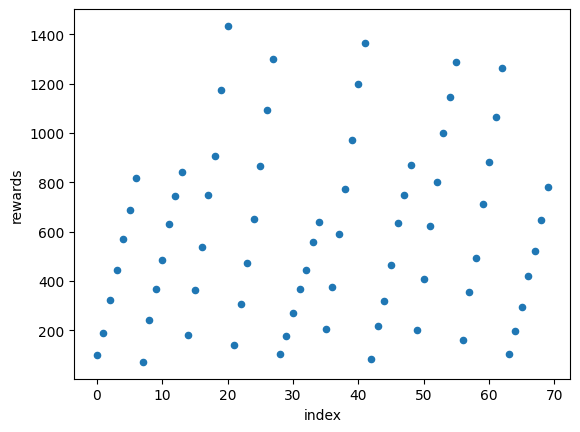

In [29]:
rewards_df.plot.scatter(x='index', y='rewards')

In [30]:
rewards_lst = []
max_reward = 0
l2_lambda = 0.01
lr = 0.001
lr_decay_factor = 0.95

grad_total_weeks = 100
simdata_folder = '../data/update_gradient/100_weeks/'

W = np.random.rand(3,13)
#pricing_params = (5, 0.78, 1.82)

#print('W:', W)

for w in tqdm(range(grad_total_weeks)):
    learning_rate = lr * (lr_decay_factor ** w)
    print("------------------------------------------------------------------------------------------")
    print('learning_rate:', learning_rate)
    pricing_params = np.random.rand(3)
    simulation_this_week = WeeklySimulation(w, learning_rate, pricing_params, None, "")
    context_prev_rewards = np.zeros(6)
    for d in range(7):
        context_day_of_week = np.zeros(7)
        context_day_of_week[d] = 1
        
        if d > 0:
            context_prev_rewards[d-1] = rewards_lst[-1] if rewards_lst[-1]>0 else 0
        
        print(f'week:%d, day:%d'%(w, d))

        context_vec = np.concatenate([context_day_of_week, context_prev_rewards])
        #print('context_vec:', context_vec)

        drivers_this_week_today = simulation_this_week.simulate_supply()
        requests_this_week_today = simulation_this_week.simulate_demand()

        simulation_this_week.request_driver_matching(verbose=0)
        simulation_this_week.update_gamma_distns()
        
        simdata_filename = 'exposed_prices_'+'week_'+str(w)+'_day_'+str(d)+'.json'
        with open(os.path.join(simdata_folder,simdata_filename), 'w') as json_file:
            json.dump(simulation_this_week.exposed_prices, json_file, indent=4)

        exposed_price_df = pd.read_json(os.path.join(simdata_folder, simdata_filename))
        print(f"num of exposed prices:%d, num of matched prices:%d"%(len(exposed_price_df), len(exposed_price_df[exposed_price_df.both_accepted==1])))

        todays_rewards = exposed_price_df[exposed_price_df.both_accepted==1]['price_of_ride'].sum() * simulation_this_week.charge_percentage
        
        if todays_rewards > max_reward:
            max_reward = todays_rewards
            print('current reward is the max reward so far')
            print('todays_rewards:', todays_rewards)
        
        rewards_lst.append(todays_rewards)

        exposed_price_df['ride_grad'] = simulation_this_week.charge_percentage*exposed_price_df.rider_acceptance_prob*exposed_price_df.driver_acceptance_prob* \
                        (1+exposed_price_df.distance_normalized_price*(\
                        (1-exposed_price_df.rider_acceptance_prob)*simulation_this_week.b_r)+(1-exposed_price_df.driver_acceptance_prob)*simulation_this_week.b_d)

        exposed_price_df['ride_gradient_theta1'] = exposed_price_df.ride_grad * 2 * exposed_price_df.trip_miles
        exposed_price_df['ride_gradient_theta2'] = exposed_price_df.ride_grad * exposed_price_df.trip_miles
        exposed_price_mean_df = exposed_price_df[['ride_grad', 'ride_gradient_theta1', 'ride_gradient_theta2']].mean()
        
        W[0] = W[0] - lr * (exposed_price_mean_df.ride_grad * context_vec + l2_lambda * W[0])
        W[1] = W[1] - lr * (exposed_price_mean_df.ride_gradient_theta1 * context_vec + l2_lambda * W[1])
        W[2] = W[2] - lr * (exposed_price_mean_df.ride_gradient_theta2 * context_vec + l2_lambda * W[2])

        pricing_params = np.matmul(W, context_vec)

        #print('W:', W)
        print('pricing_params:', pricing_params)

  0%|          | 0/100 [00:00<?, ?it/s]

------------------------------------------------------------------------------------------
learning_rate: 0.001
week:0, day:0
num of exposed prices:133, num of matched prices:69
current reward is the max reward so far
todays_rewards: 130.13214
pricing_params: [0.88064463 0.88284722 0.25942499]
week:0, day:1
num of exposed prices:298, num of matched prices:157
current reward is the max reward so far
todays_rewards: 312.31712999999996
pricing_params: [43.79116902 85.33249121 70.2265984 ]
week:0, day:2
num of exposed prices:394, num of matched prices:208
current reward is the max reward so far
todays_rewards: 408.84279
pricing_params: [314.56153171 180.23538815 274.81220791]
week:0, day:3


  1%|          | 1/100 [00:00<00:40,  2.45it/s]

num of exposed prices:499, num of matched prices:277
current reward is the max reward so far
todays_rewards: 549.6448199999999
pricing_params: [414.95769947 111.53776652 278.91070253]
week:0, day:4
num of exposed prices:626, num of matched prices:350
current reward is the max reward so far
todays_rewards: 689.3947800000001
pricing_params: [ 618.76518118 -449.15186867  -15.14449302]
week:0, day:5
num of exposed prices:706, num of matched prices:393
current reward is the max reward so far
todays_rewards: 770.82339
pricing_params: [  654.85387217 -1637.13528401  -369.39819866]
week:0, day:6
num of exposed prices:811, num of matched prices:459
current reward is the max reward so far
todays_rewards: 897.87843
pricing_params: [  936.27697987 -3835.68125737 -1028.9195898 ]
------------------------------------------------------------------------------------------
learning_rate: 0.00095
week:1, day:0
num of exposed prices:137, num of matched prices:70
pricing_params: [0.88045446 0.88139326 0.25

  2%|▏         | 2/100 [00:00<00:40,  2.40it/s]

...

num of exposed prices:811, num of matched prices:394
pricing_params: [ -87557.58116187 -978853.91330947 -488023.99816818]
------------------------------------------------------------------------------------------
learning_rate: 6.560143180425483e-06
week:98, day:0
num of exposed prices:116, num of matched prices:58
pricing_params: [0.86193879 0.7377762  0.18813372]
week:98, day:1
num of exposed prices:227, num of matched prices:112
pricing_params: [ -2725.44558776 -30464.64244073 -15186.13280554]
week:98, day:2
num of exposed prices:360, num of matched prices:176
pricing_params: [ -11494.84320228 -130264.39987426  -64874.4430808 ]
week:98, day:3
num of exposed prices:485, num of matched prices:242
pricing_params: [ -28938.48334373 -322961.7465779  -161159.71796105]
week:98, day:4
num of exposed prices:610, num of matched prices:296
pricing_params: [ -52558.46338914 -585782.80751699 -292592.5447622 ]
week:98, day:5
num of exposed prices:733, num of matched prices:365
pricing_params: [ -

 99%|█████████▉| 99/100 [00:41<00:00,  2.24it/s]

num of exposed prices:841, num of matched prices:429
pricing_params: [  -94338.81404483 -1053976.72811463  -525546.58243408]
------------------------------------------------------------------------------------------
learning_rate: 6.2321360214042085e-06
week:99, day:0
num of exposed prices:114, num of matched prices:61
pricing_params: [0.86174241 0.73620344 0.18736   ]
week:99, day:1
num of exposed prices:208, num of matched prices:118
pricing_params: [ -1997.84914642 -22329.03116731 -11131.01674856]
week:99, day:2
num of exposed prices:330, num of matched prices:181
pricing_params: [ -8523.30745806 -96562.72129259 -48092.0936177 ]
week:99, day:3


100%|██████████| 100/100 [00:41<00:00,  2.39it/s]

num of exposed prices:448, num of matched prices:242
pricing_params: [ -20775.81485074 -231889.16868913 -115711.41659232]
week:99, day:4
num of exposed prices:561, num of matched prices:299
pricing_params: [ -37161.74333382 -414155.13731454 -206859.82702573]
week:99, day:5
num of exposed prices:663, num of matched prices:346
pricing_params: [ -54046.80714086 -600383.44104307 -299710.62080949]
week:99, day:6
num of exposed prices:801, num of matched prices:418
pricing_params: [ -65451.08500411 -730892.98885534 -364469.48302309]


In [31]:
rewards_df = pd.DataFrame({'rewards': rewards_lst}).reset_index()

In [36]:
rewards_df['week_idx'] = (rewards_df.index // 7)

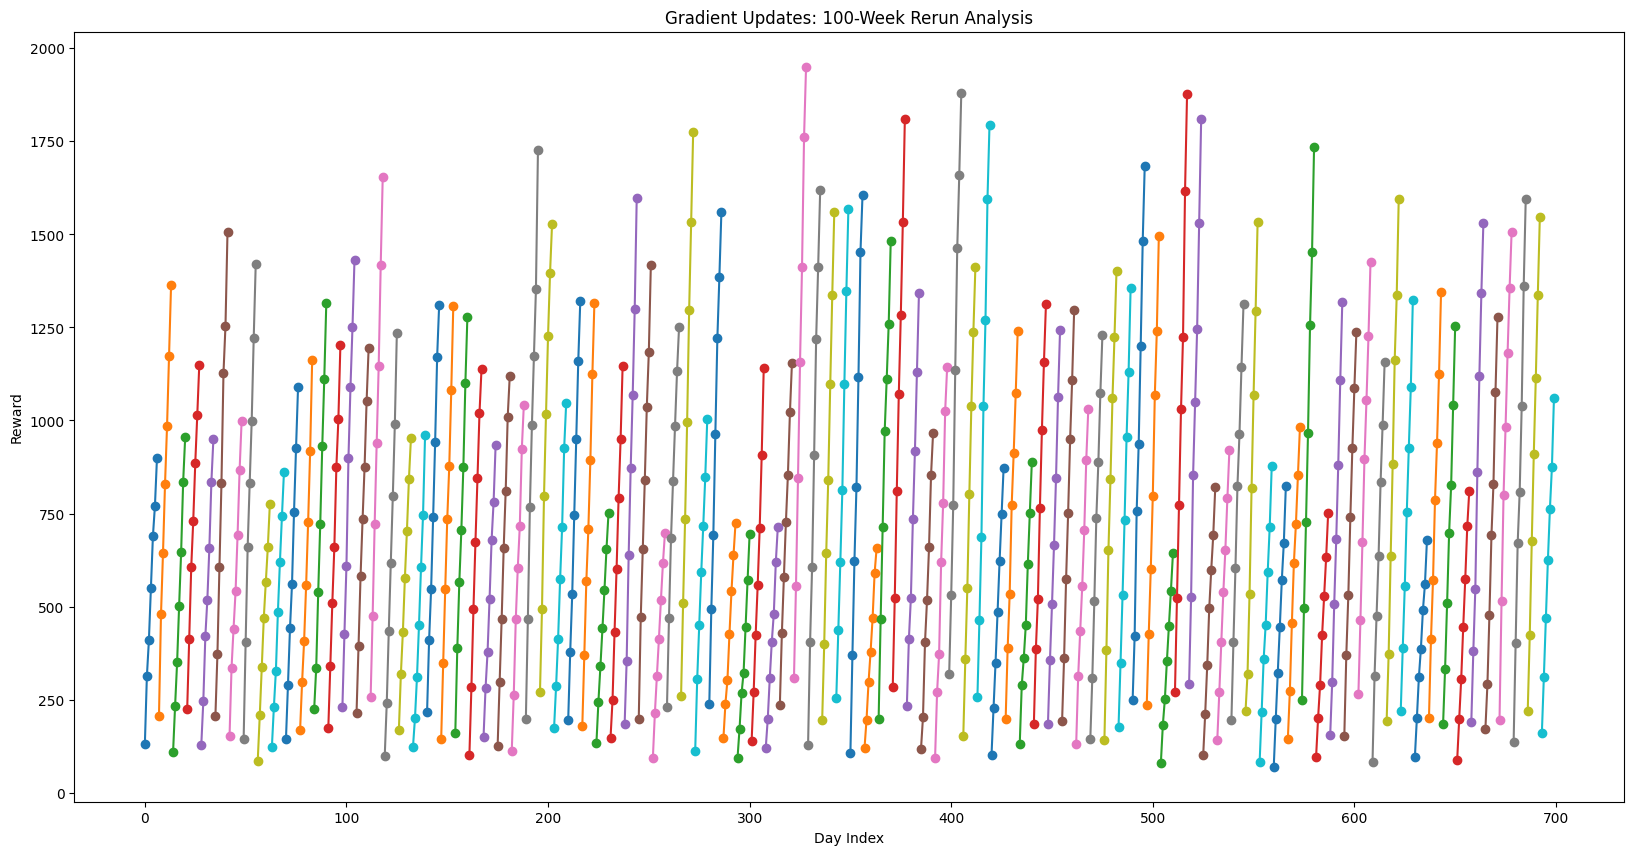

In [49]:
plt.figure(figsize=(20, 10))
plt.scatter(rewards_df['index'], rewards_df['rewards'], c=rewards_df['week_idx'], cmap='viridis', s=10)
for group, group_data in rewards_df.groupby('week_idx'):
    plt.plot(group_data['index'], group_data['rewards'], marker='o', linestyle='-', label=f'Group {group}')

plt.title("Gradient Updates: 100-Week Rerun Analysis")
plt.xlabel("Day Index")
plt.ylabel("Reward")
plt.show()

In [35]:
rewards_df.max()

index       699.00000
rewards    1950.52578
dtype: float64

In [50]:
rewards_df[rewards_df.rewards==1950.52578]

,index,rewards,week_idx
328,328,1950.52578,46


In [3]:
rewards_lst = []
max_reward = 0
l2_lambda = 0.01
lr = 0.001
lr_decay_factor = 0.95

grad_total_weeks = 100
simdata_folder = '../data/update_gradient/100_weeks/'

W = np.random.rand(3,13)
#pricing_params = (5, 0.78, 1.82)

#print('W:', W)

for w in tqdm(range(grad_total_weeks)):
    learning_rate = lr * (lr_decay_factor ** w)
    print("------------------------------------------------------------------------------------------")
    print('learning_rate:', learning_rate)
    pricing_params = np.random.rand(3)
    simulation_this_week = WeeklySimulation(w, learning_rate, pricing_params, None, "")
    context_prev_rewards = np.zeros(6)
    for d in range(7):
        context_day_of_week = np.zeros(7)
        context_day_of_week[d] = 1
        
        if d > 0:
            context_prev_rewards[d-1] = rewards_lst[-1] if rewards_lst[-1]>0 else 0
        
        print(f'week:%d, day:%d'%(w, d))

        context_vec = np.concatenate([context_day_of_week, context_prev_rewards])
        #print('context_vec:', context_vec)

        drivers_this_week_today = simulation_this_week.simulate_supply()
        requests_this_week_today = simulation_this_week.simulate_demand()
        print("simulation_this_week.daily_num_requests:", simulation_this_week.daily_num_requests.sum().int().item())

        simulation_this_week.request_driver_matching(verbose=0)
        simulation_this_week.update_gamma_distns()
        
        simdata_filename = 'exposed_prices_'+'week_'+str(w)+'_day_'+str(d)+'.json'
        with open(os.path.join(simdata_folder,simdata_filename), 'w') as json_file:
            json.dump(simulation_this_week.exposed_prices, json_file, indent=4)

        exposed_price_df = pd.read_json(os.path.join(simdata_folder, simdata_filename))
        print(f"num of exposed prices:%d, num of matched prices:%d"%(len(exposed_price_df), len(exposed_price_df[exposed_price_df.both_accepted==1])))

        todays_rewards = exposed_price_df[exposed_price_df.both_accepted==1]['price_of_ride'].sum() * simulation_this_week.charge_percentage
        
        if todays_rewards > max_reward:
            max_reward = todays_rewards
            print('current reward is the max reward so far')
            print('todays_rewards:', todays_rewards)
        
        rewards_lst.append(todays_rewards)

        exposed_price_df['ride_grad'] = simulation_this_week.charge_percentage*exposed_price_df.rider_acceptance_prob*exposed_price_df.driver_acceptance_prob* \
                        (1+exposed_price_df.distance_normalized_price*(\
                        (1-exposed_price_df.rider_acceptance_prob)*simulation_this_week.b_r)+(1-exposed_price_df.driver_acceptance_prob)*simulation_this_week.b_d)

        exposed_price_df['ride_gradient_theta1'] = exposed_price_df.ride_grad * 2 * exposed_price_df.trip_miles
        exposed_price_df['ride_gradient_theta2'] = exposed_price_df.ride_grad * exposed_price_df.trip_miles
        exposed_price_mean_df = exposed_price_df[['ride_grad', 'ride_gradient_theta1', 'ride_gradient_theta2']].mean()
        
        W[0] = W[0] + lr * (exposed_price_mean_df.ride_grad * context_vec + l2_lambda * W[0])
        W[1] = W[1] + lr * (exposed_price_mean_df.ride_gradient_theta1 * context_vec + l2_lambda * W[1])
        W[2] = W[2] + lr * (exposed_price_mean_df.ride_gradient_theta2 * context_vec + l2_lambda * W[2])

        pricing_params = np.matmul(W, context_vec)

        #print('W:', W)
        print('pricing_params:', pricing_params)

  0%|          | 0/1 [00:00<?, ?it/s]

------------------------------------------------------------------------------------------
learning_rate: 0.001
week:0, day:0
simulation_this_week.daily_num_requests: 863
num of exposed prices:646, num of matched prices:297
current reward is the max reward so far
todays_rewards: 1226.10972
pricing_params: [0.58347212 0.62669956 0.52031906]
week:0, day:1
simulation_this_week.daily_num_requests: 881
num of exposed prices:674, num of matched prices:327
current reward is the max reward so far
todays_rewards: 1275.5199599999999
pricing_params: [ 884.99659193 2106.6079649  2086.73528856]
week:0, day:2
simulation_this_week.daily_num_requests: 870
num of exposed prices:655, num of matched prices:320
pricing_params: [2107.05034681 5912.39591703 4369.93837722]
week:0, day:3
simulation_this_week.daily_num_requests: 953
num of exposed prices:706, num of matched prices:351
current reward is the max reward so far
todays_rewards: 1408.4155499999997
pricing_params: [ 2903.6026644  12639.22325036  7388

100%|██████████| 1/1 [00:00<00:00,  1.05it/s]

num of exposed prices:683, num of matched prices:348
current reward is the max reward so far
todays_rewards: 1410.3765899999999
pricing_params: [ 5847.09547885 31601.42795662 17436.88181514]
week:0, day:6
simulation_this_week.daily_num_requests: 855
num of exposed prices:595, num of matched prices:279
pricing_params: [ 7454.24995347 44322.79886461 24438.41488738]


In [4]:
rewards_df = pd.DataFrame({'rewards': rewards_lst}).reset_index()
rewards_df['week_idx'] = (rewards_df.index // 7)

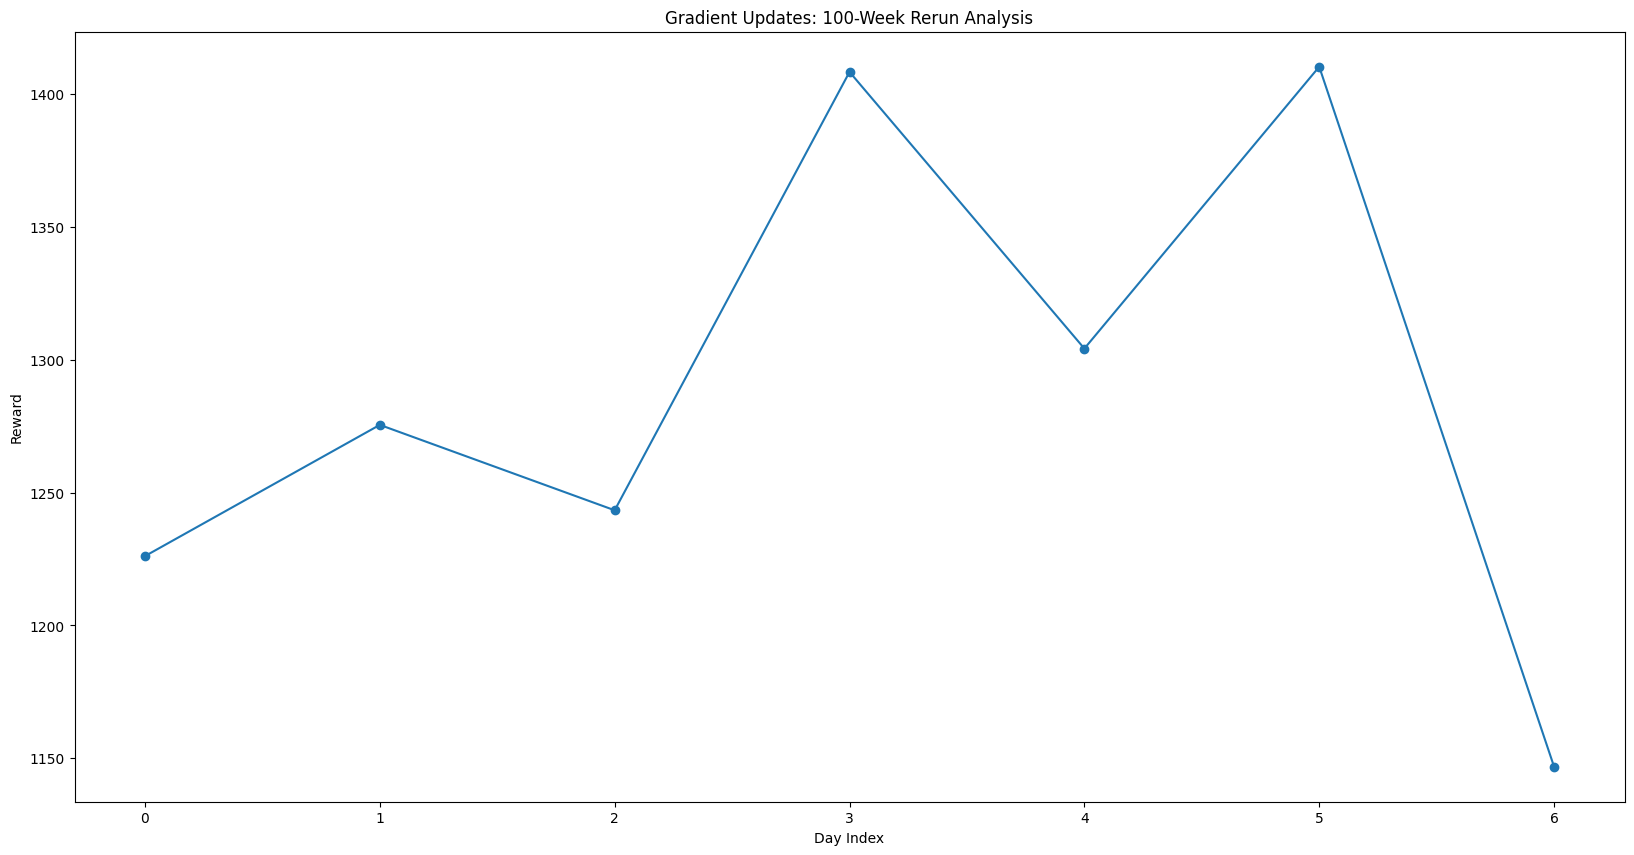

In [5]:
plt.figure(figsize=(20, 10))
plt.scatter(rewards_df['index'], rewards_df['rewards'], c=rewards_df['week_idx'], cmap='viridis', s=10)
for group, group_data in rewards_df.groupby('week_idx'):
    plt.plot(group_data['index'], group_data['rewards'], marker='o', linestyle='-', label=f'Group {group}')

plt.title("Gradient Updates: 100-Week Rerun Analysis")
plt.xlabel("Day Index")
plt.ylabel("Reward")
plt.show()